In [14]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [4]:
fashion_train_df = pd.read_csv('fashion-mnist_train.csv',sep = ',')

In [5]:
fashion_test_df = pd.read_csv('fashion-mnist_test.csv',sep=',')

In [6]:
fashion_train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
fashion_test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
fashion_train_df.shape

(60000, 785)

In [9]:
fashion_test_df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [10]:
training = np.array(fashion_train_df,dtype='float32')

In [11]:
testing = np.array(fashion_test_df,dtype='float32')

In [16]:
i = random.randint(1,60000)

np.float32(2.0)

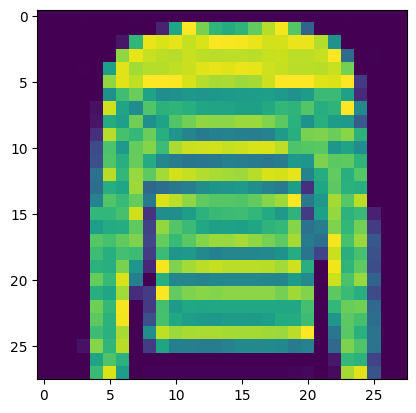

In [18]:
plt.imshow(training[i,1:].reshape(28,28))
label = training[i,0]
label

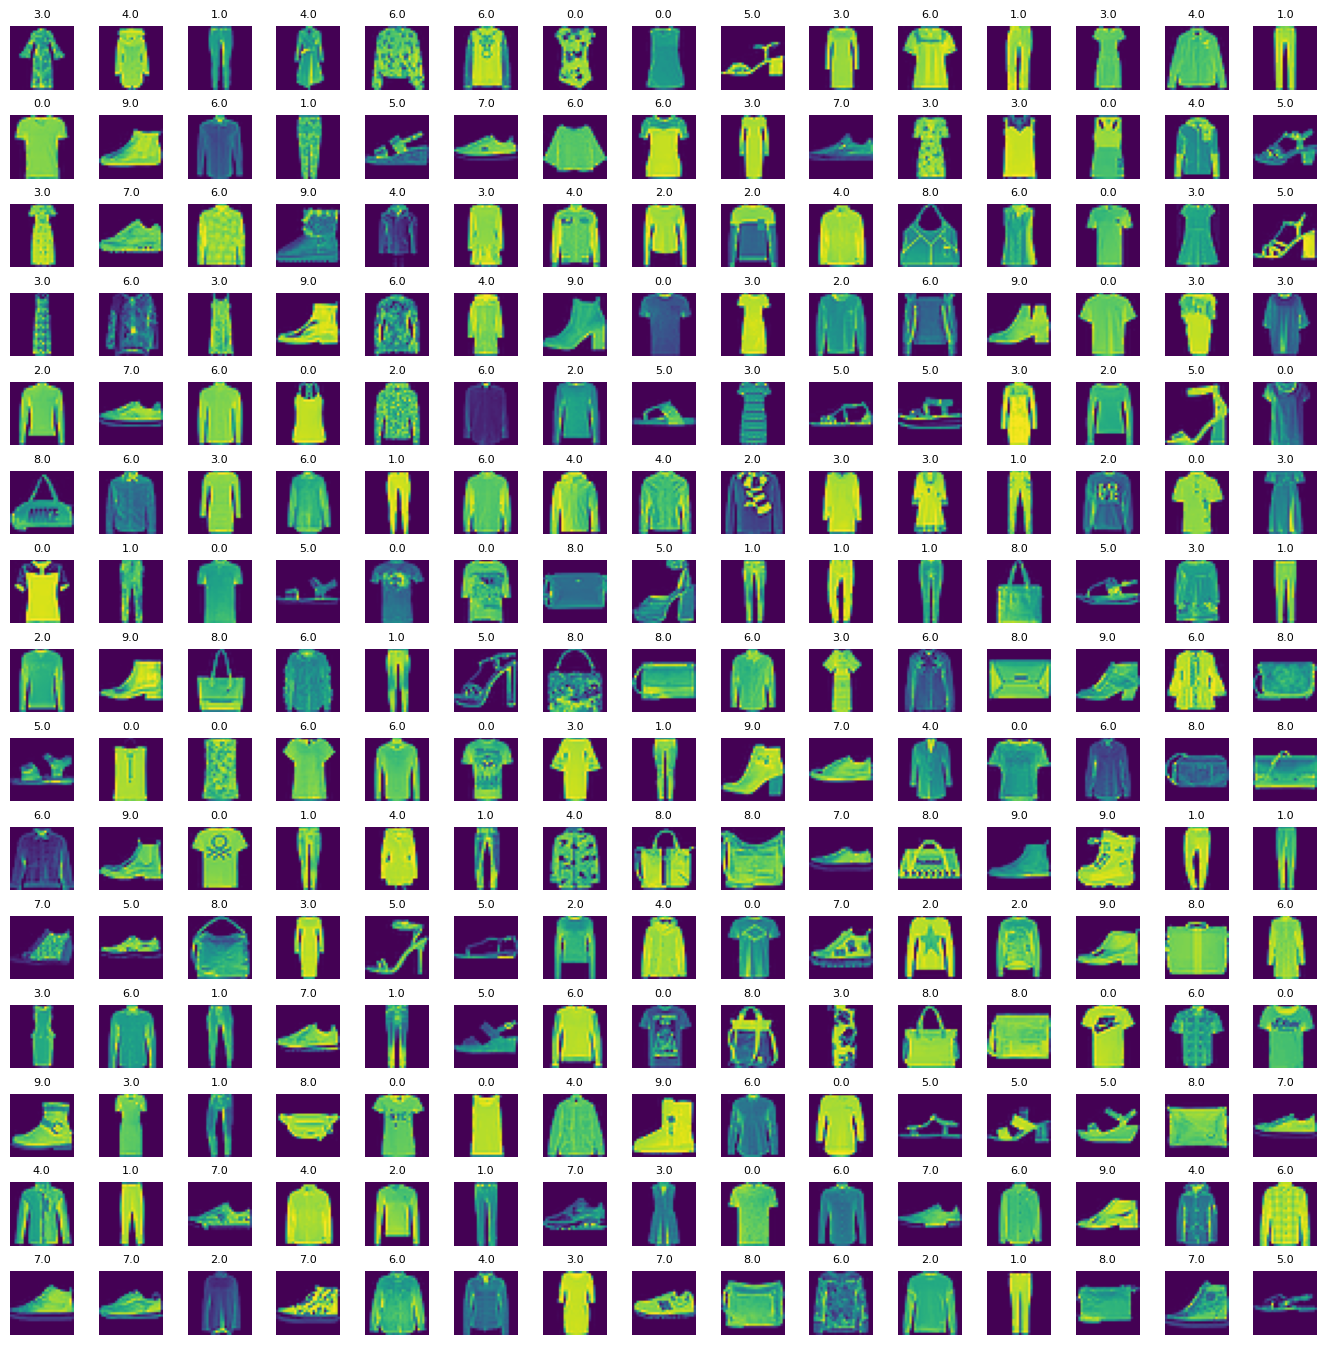

In [21]:
w_grid = 15
l_grid = 15 


fig, axes = plt.subplots(l_grid,w_grid, figsize = (17,17))

axes = axes.ravel()

n_training = len(training)


for i in np.arange(0,w_grid*l_grid):
    index = np.random.randint(0,n_training)
    axes[i].imshow(training[index,1:].reshape((28,28)))
    axes[i].set_title(training[index,0],fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

In [22]:
X_train = training[:, 1:] / 255 
y_train = training[:, 0]

In [23]:
X_test = testing[:, 1:] / 255 
y_test = testing[:, 0]

In [24]:
from sklearn.model_selection import train_test_split



In [25]:
X_train,X_validate , y_train , y_validate = train_test_split(X_train,y_train,test_size=0.2,random_state=12345)

In [28]:
X_train = X_train.reshape(X_train.shape[0], * (28,28,1))
X_test = X_test.reshape(X_test.shape[0],*(28,28,1))
X_validate = X_validate.reshape(X_validate.shape[0], *(28,28,1))

In [29]:
X_train.shape

(48000, 28, 28, 1)

In [30]:
import keras

In [60]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D , Dense , Flatten , Dropout
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

In [32]:
cnn_model = Sequential()

In [61]:
cnn_model = Sequential()
cnn_model.add(Input(shape=(28, 28, 1)))
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))

In [62]:
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

In [63]:
cnn_model.add(Flatten())

In [64]:
cnn_model.add(Dense(units = 32,activation='relu'))

In [65]:
cnn_model.add(Dense(units = 10,activation='sigmoid'))

In [66]:
cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=  0.001),metrics=['accuracy'])

In [43]:
epochs = 50

In [67]:
cnn_model.fit(
    X_train,
    y=y_train,
    batch_size= 512 , 
    epochs= epochs,
    verbose= 1,
    validation_data= (X_validate,y_validate)
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7436 - loss: 0.7687 - val_accuracy: 0.8372 - val_loss: 0.4637
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8520 - loss: 0.4224 - val_accuracy: 0.8633 - val_loss: 0.3937
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8728 - loss: 0.3663 - val_accuracy: 0.8746 - val_loss: 0.3619
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8827 - loss: 0.3368 - val_accuracy: 0.8837 - val_loss: 0.3386
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8921 - loss: 0.3120 - val_accuracy: 0.8927 - val_loss: 0.3148
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8985 - loss: 0.2933 - val_accuracy: 0.8982 - val_loss: 0.2958
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8992 - loss: 0.2835 - val_accuracy: 0.9022 - val_loss: 0.2875
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9046 - loss: 0.2725 - val_accuracy: 0.9014 - v

In [68]:
evaluation = cnn_model.evaluate(X_test,y_test)
print('Test Accuracy : {:.3f}'.format(evaluation[1]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9188 - loss: 0.2747
Test Accuracy : 0.919


In [69]:
predicted_classes = np.argmax(cnn_model.predict(X_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [70]:
predicted_classes

array([0, 1, 2, ..., 8, 8, 1], shape=(10000,))

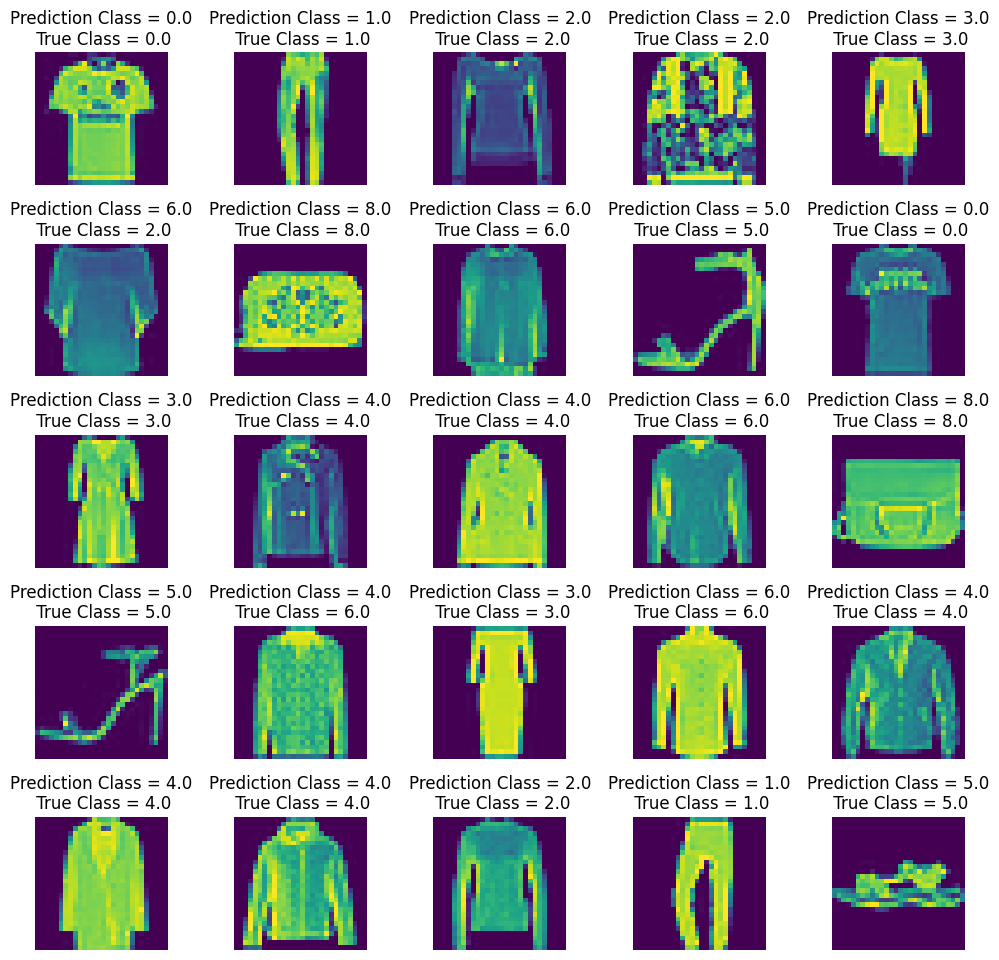

In [71]:
L = 5
W = 5 
fig , axes = plt.subplots(L,W,figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(X_test[i].reshape(28,28))
    axes[i].set_title("Prediction Class = {:0.1f}\n True Class = {:0.1f}".format(predicted_classes[i],y_test[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)

<Axes: >

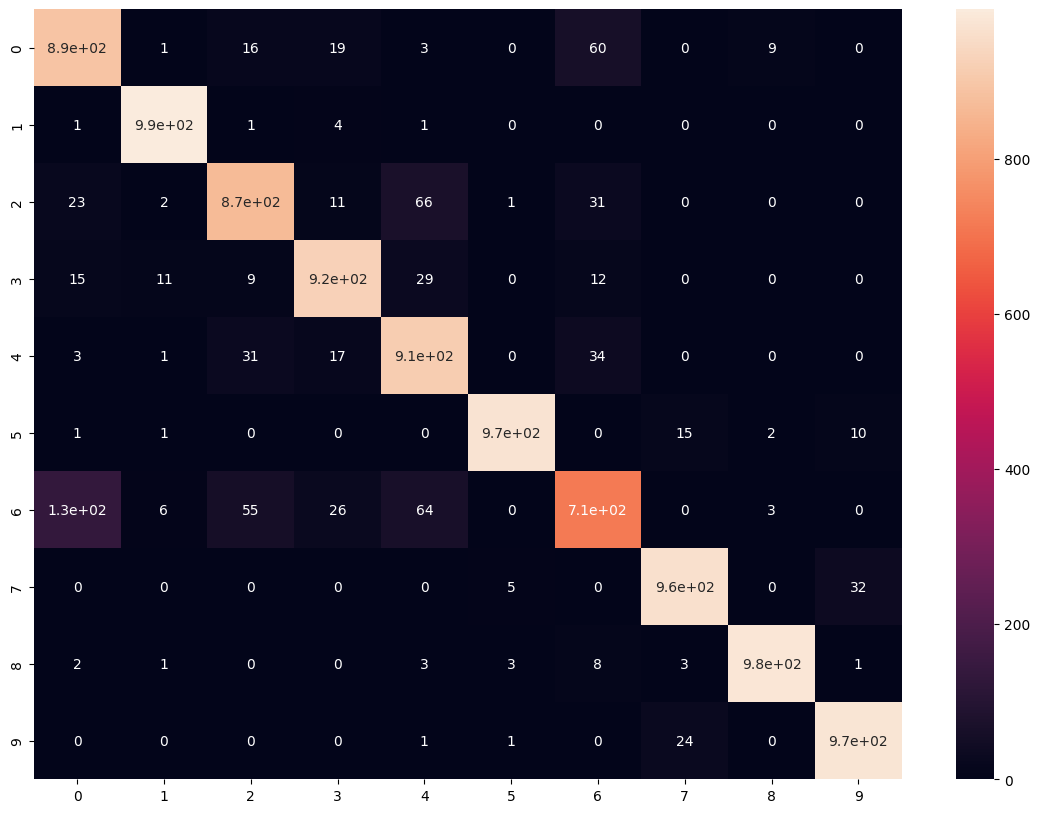

In [72]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(14,10))
sns.heatmap(cm,annot=True)

In [73]:
from sklearn.metrics import classification_report

num_classes = 10

target_names = ["Class: {}".format(i) for i in range(num_classes)]

print(classification_report(y_test,predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

    Class: 0       0.83      0.89      0.86      1000
    Class: 1       0.98      0.99      0.99      1000
    Class: 2       0.89      0.87      0.88      1000
    Class: 3       0.92      0.92      0.92      1000
    Class: 4       0.85      0.91      0.88      1000
    Class: 5       0.99      0.97      0.98      1000
    Class: 6       0.83      0.71      0.77      1000
    Class: 7       0.96      0.96      0.96      1000
    Class: 8       0.99      0.98      0.98      1000
    Class: 9       0.96      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

